In [9]:
import pandas as pd
from support_research import *
import matplotlib.pyplot as plt
from load_data import load_data
from optimal_parameters import *


In [10]:
bitcoin_data, eth_data, xrp_data = load_data()


c:\Users\MrlJu\Documents\REPOSITORIES\Tyche\research\notebooks\load_data.py:10: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Call ffill before calling pct_change to retain current behavior and silence this warning.
  bitcoin_data['return'] = bitcoin_data['Close'].pct_change()


In [16]:
bitcoin_data = construct_signals(bitcoin_data, window=10, horizon=15, k=30, n=0)

In [13]:
bitcoin_data = construct_targets(bitcoin_data, horizon=15)

c:\Users\MrlJu\Documents\REPOSITORIES\Tyche\research\notebooks\load_data.py:17: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Call ffill before calling pct_change to retain current behavior and silence this warning.
  data['return_horizon_for_target'] = data['Close'].pct_change(horizon)


In [14]:
bitcoin_data

,Datetime,Open,High,Low,Close,Volume,return,signal,signal_std,filter,filtered_signal,return_horizon_for_target,target
0,2009-01-03T00:00:00Z,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-04T00:00:00Z,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-01-05T00:00:00Z,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-01-06T00:00:00Z,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-01-07T00:00:00Z,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6247,2026-02-10T00:00:00Z,70150.683023,70490.652368,67821.937475,68825.556888,39300.735830,-0.018864,0.054578,0.094480,1.0,0.054578,-0.220413,NaN
6248,2026-02-11T00:00:00Z,68801.503665,69256.227670,65742.270390,67047.971604,54217.542483,-0.025827,0.033775,0.090764,1.0,0.033775,-0.247871,NaN
6249,2026-02-12T00:00:00Z,67033.860224,68440.656734,65069.225436,66264.419740,46620.756126,-0.011686,0.079150,0.080541,1.0,0.079150,-0.256822,NaN
6250,2026-02-13T00:00:00Z,66220.091095,69448.024394,65819.248705,68813.948587,41351.964632,0.038475,0.023840,0.091950,1.0,0.023840,-0.187160,NaN


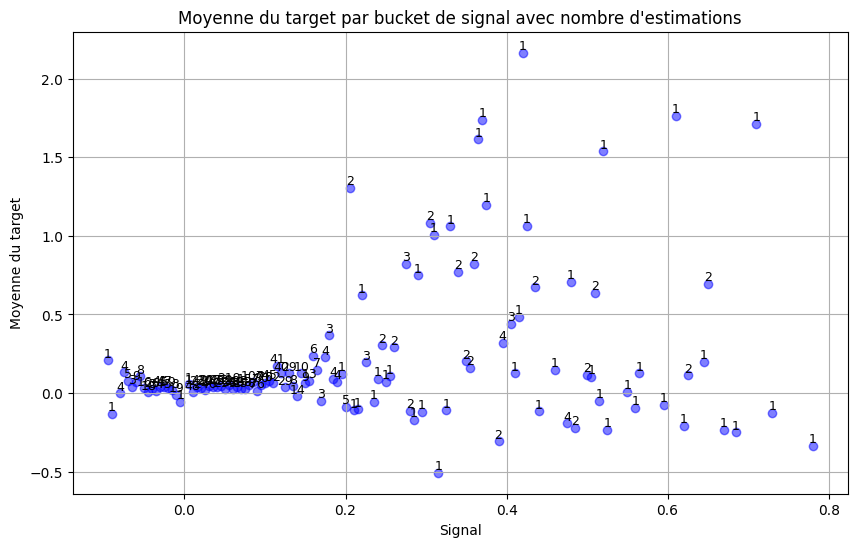

In [17]:
import matplotlib.pyplot as plt

# Créer les buckets
bitcoin_data['signal_bucket'] = round(bitcoin_data['filtered_signal'] / 0.005) * 0.005  # bucket de 0.5%
trace = bitcoin_data.groupby('signal_bucket')['target'].mean()
counts = bitcoin_data.groupby('signal_bucket')['target'].count()  # nombre d'estimations par bucket

plt.figure(figsize=(10, 6))
plt.scatter(trace.index, trace.values, alpha=0.5, color='blue')

# Ajouter le nombre d'estimations au-dessus des points
for x, y, c in zip(trace.index, trace.values, counts):
    plt.text(x, y + 0.001, str(c), ha='center', va='bottom', fontsize=9)

plt.xlabel('Signal')
plt.ylabel('Moyenne du target')
plt.title('Moyenne du target par bucket de signal avec nombre d\'estimations')
plt.grid(True)
plt.show()

In [4]:
bitcoin_data

,Datetime,Open,High,Low,Close,Volume,return,signal,signal_std,filter,filtered_signal
0,2009-01-03T00:00:00Z,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
1,2009-01-04T00:00:00Z,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
2,2009-01-05T00:00:00Z,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
3,2009-01-06T00:00:00Z,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
4,2009-01-07T00:00:00Z,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
6247,2026-02-10T00:00:00Z,70150.683023,70490.652368,67821.937475,68825.556888,39300.735830,-0.018864,0.005967,0.024918,1.0,0.005967
6248,2026-02-11T00:00:00Z,68801.503665,69256.227670,65742.270390,67047.971604,54217.542483,-0.025827,-0.002924,0.021669,1.0,-0.002924
6249,2026-02-12T00:00:00Z,67033.860224,68440.656734,65069.225436,66264.419740,46620.756126,-0.011686,0.001036,0.021420,NaN,NaN
6250,2026-02-13T00:00:00Z,66220.091095,69448.024394,65819.248705,68813.948587,41351.964632,0.038475,-0.011328,0.029792,1.0,-0.011328


In [5]:
param_grid = {
    "window": [2, 5, 10, 20, 30],
    "horizon": [1, 3, 5, 10, 15],
    "k": [5, 10, 20, 30],
    "n": [0],
    "threshold": [0.1]
}

In [6]:
df_results = evaluate_params_wrapper(bitcoin_data, param_grid=param_grid)

c:\Users\MrlJu\Documents\REPOSITORIES\Tyche\research\notebooks\load_data.py:17: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Call ffill before calling pct_change to retain current behavior and silence this warning.
  data['return_horizon_for_target'] = data['Close'].pct_change(horizon)
c:\Users\MrlJu\Documents\REPOSITORIES\Tyche\research\notebooks\load_data.py:17: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Call ffill before calling pct_change to retain current behavior and silence this warning.
  data['return_horizon_for_target'] = data['Close'].pct_change(horizon)
c:\Users\MrlJu\Documents\REPOSITORIES\Tyche\research\notebooks\load_data.py:17: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Call ffill before calling pct_change to retain current behavior and silen

In [7]:
df_results

[{'window': 2,
  'horizon': 1,
  'k': 5,
  'n': 0,
  'threshold': 0.1,
  'correlation': 0.012156679250631972},
 {'window': 2,
  'horizon': 1,
  'k': 10,
  'n': 0,
  'threshold': 0.1,
  'correlation': 0.02823448515553743},
 {'window': 2,
  'horizon': 1,
  'k': 20,
  'n': 0,
  'threshold': 0.1,
  'correlation': 0.05316849488738761},
 {'window': 2,
  'horizon': 1,
  'k': 30,
  'n': 0,
  'threshold': 0.1,
  'correlation': 0.041345615528354626},
 {'window': 2,
  'horizon': 3,
  'k': 5,
  'n': 0,
  'threshold': 0.1,
  'correlation': 0.03550222997341014},
 {'window': 2,
  'horizon': 3,
  'k': 10,
  'n': 0,
  'threshold': 0.1,
  'correlation': 0.041955609628764275},
 {'window': 2,
  'horizon': 3,
  'k': 20,
  'n': 0,
  'threshold': 0.1,
  'correlation': 0.0514197493042836},
 {'window': 2,
  'horizon': 3,
  'k': 30,
  'n': 0,
  'threshold': 0.1,
  'correlation': 0.061181703178883204},
 {'window': 2,
  'horizon': 5,
  'k': 5,
  'n': 0,
  'threshold': 0.1,
  'correlation': 0.04158560407942973},
 

In [8]:
df = pd.DataFrame(df_results)

# Tri par corrélation décroissante
df_sorted = df.sort_values(by='correlation', ascending=False)

print(df_sorted)

    window  horizon   k  n  threshold  correlation
56      10       15   5  0        0.1     0.212169
58      10       15  20  0        0.1     0.210599
57      10       15  10  0        0.1     0.209815
39       5       15  30  0        0.1     0.204126
59      10       15  30  0        0.1     0.201011
..     ...      ...  .. ..        ...          ...
0        2        1   5  0        0.1     0.012157
81      30        1  10  0        0.1    -0.000795
61      20        1  10  0        0.1    -0.000808
80      30        1   5  0        0.1    -0.003839
60      20        1   5  0        0.1    -0.014165

[100 rows x 6 columns]


In [ ]:
bitcoin_data['signal'] = bitcoin_data['return'].rolling(window=1000).apply(lambda x: applicate_mean(x, window=10, horizon=1, k=20, n=10))
bitcoin_data['signal_std'] = bitcoin_data['return'].rolling(window=1000).apply(lambda x: applicate_std(x, window=10, horizon=1, k=20, n=10))
bitcoin_data['filter'] = np.where(abs(bitcoin_data['signal'] / bitcoin_data['signal_std']) > 0.1, 1, np.nan)
bitcoin_data['filtered_signal'] = bitcoin_data['signal'] * bitcoin_data['filter']

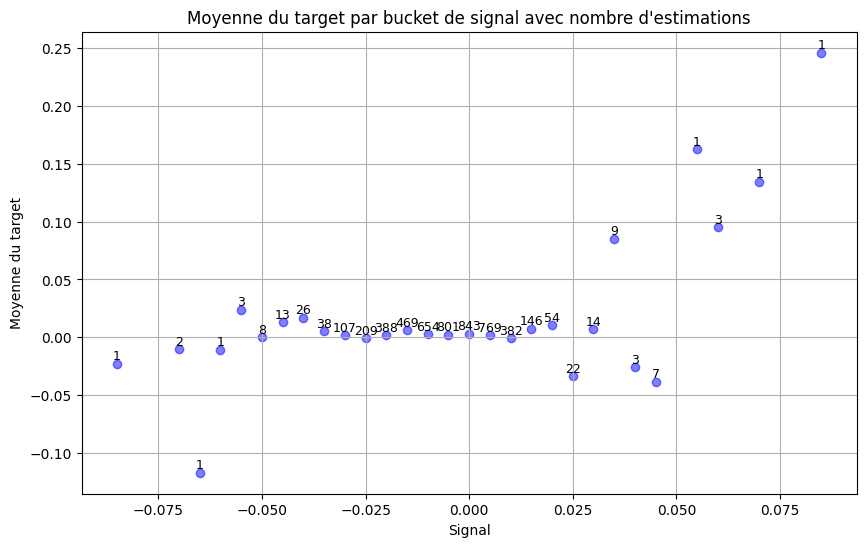

In [ ]:
import matplotlib.pyplot as plt

# Créer les buckets
bitcoin_data['signal_bucket'] = round(bitcoin_data['signal'] / 0.005) * 0.005  # bucket de 0.5%
trace = bitcoin_data.groupby('signal_bucket')['target'].mean()
counts = bitcoin_data.groupby('signal_bucket')['target'].count()  # nombre d'estimations par bucket

plt.figure(figsize=(10, 6))
plt.scatter(trace.index, trace.values, alpha=0.5, color='blue')

# Ajouter le nombre d'estimations au-dessus des points
for x, y, c in zip(trace.index, trace.values, counts):
    plt.text(x, y + 0.001, str(c), ha='center', va='bottom', fontsize=9)

plt.xlabel('Signal')
plt.ylabel('Moyenne du target')
plt.title('Moyenne du target par bucket de signal avec nombre d\'estimations')
plt.grid(True)
plt.show()


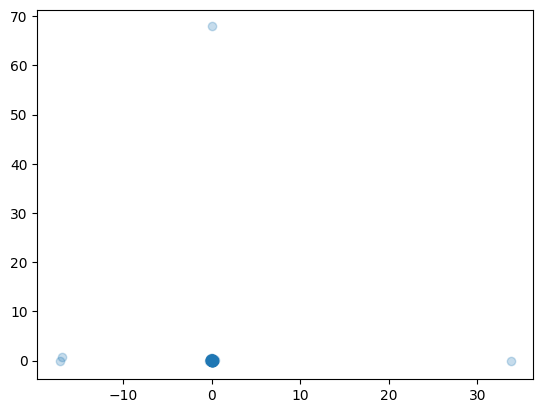

In [8]:
plt.scatter(bitcoin_data['signal'], bitcoin_data['return'].shift(-1), alpha=0.25)